In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from cascade.agents.db_orm import TrajectoryDB, DBTrainingFrame, DBTrajectoryFrame

In [2]:
db_url = 'postgresql://ase:pw@localhost:5432/cascade'
db = TrajectoryDB(db_url)
run_id = '2026.09.03-22:03:35-e79143'

In [3]:
def load_rejected_uq_error(db, run_id, traj_id):
    with db.session() as sess:
        frame_rows = sess.query(DBTrajectoryFrame).filter_by(run_id=run_id, traj_id=traj_id).all()
        frame_id_to_chunk_attempt = {f.id: (f.chunk_id, f.attempt_index) for f in frame_rows}

        train_rows = sess.query(DBTrainingFrame).filter_by(run_id=run_id, traj_id=traj_id).all()
        records = []
        for row in train_rows:
            loc = frame_id_to_chunk_attempt.get(row.trajectory_frame_id)
            if loc is None:
                continue
            chunk_id, attempt_index = loc
            records.append({
                'chunk_id': chunk_id,
                'attempt_index': attempt_index,
                'calibration_uq': row.calibration_uq,
                'calibration_error': row.calibration_error,
            })
    return pd.DataFrame(records)

In [4]:
rejected_data = {traj_id: load_rejected_uq_error(db, run_id, traj_id) for traj_id in [0, 1, 2]}

In [5]:
def plot_chunk_uq_vs_error(traj_id, chunk_id, sub):
    fig, ax = plt.subplots(figsize=(5, 4))
    for attempt_index in sorted(sub['attempt_index'].unique()):
        s = sub[sub['attempt_index'] == attempt_index]
        if len(s) >= 2:
            rho, _ = spearmanr(s['calibration_uq'], s['calibration_error'])
            label = f'attempt {attempt_index} (ρ={rho:.2f})'
        else:
            label = f'attempt {attempt_index} (n={len(s)})'
        ax.scatter(s['calibration_uq'], s['calibration_error'], label=label, alpha=0.7)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('UQ at sample time')
    ax.set_ylabel('observed force error')
    ax.set_title(f'Traj {traj_id} chunk {chunk_id}: rejected, UQ vs error')
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

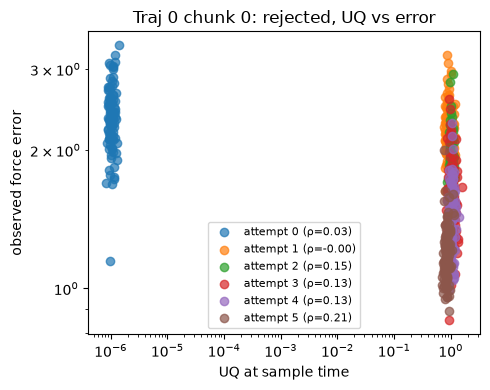

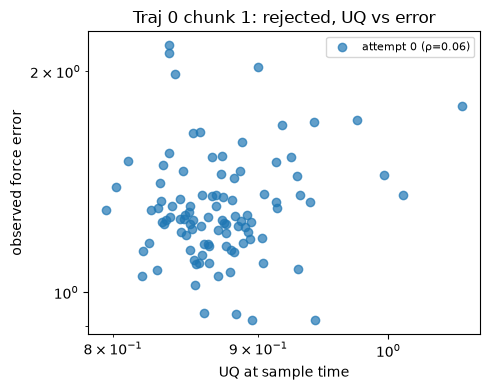

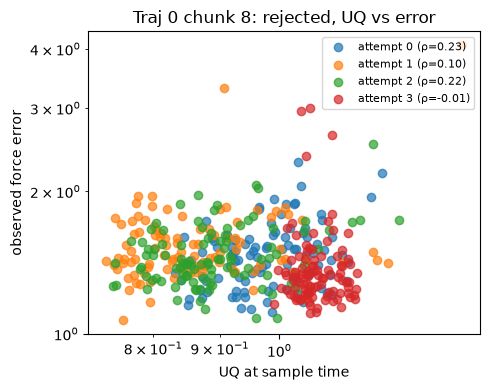

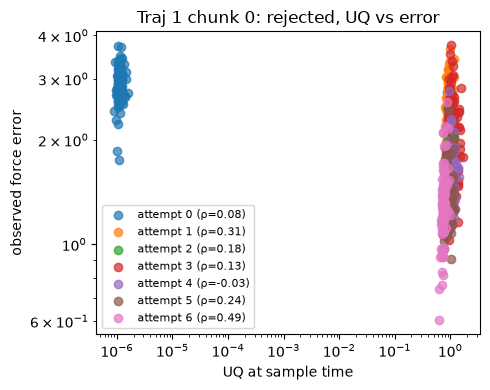

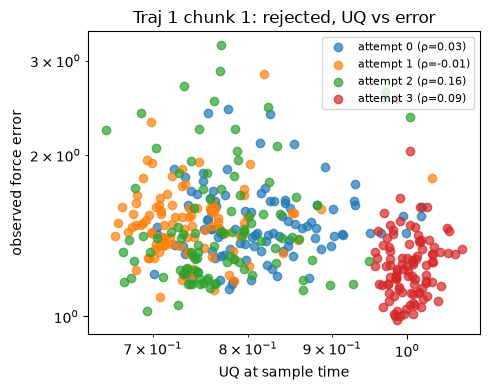

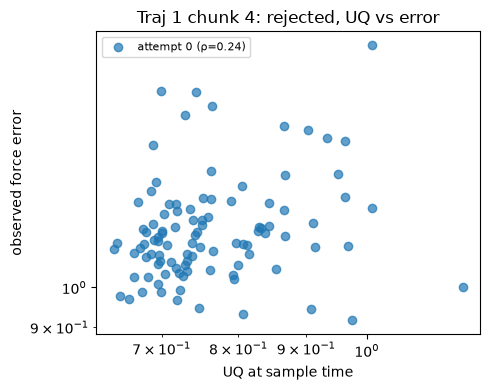

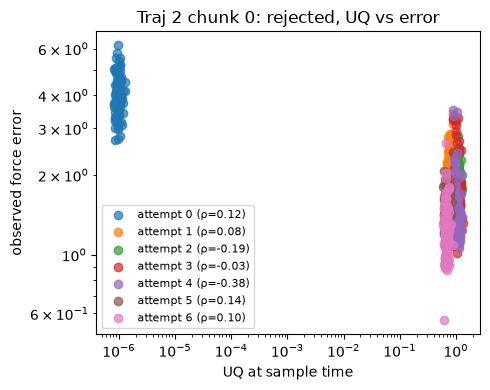

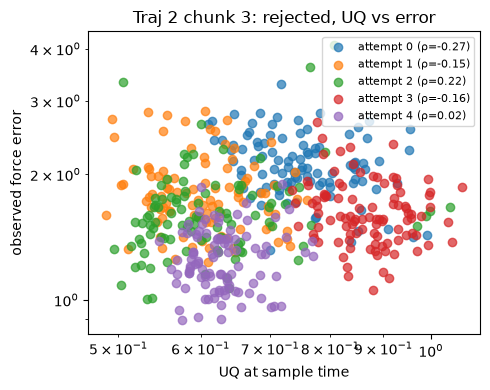

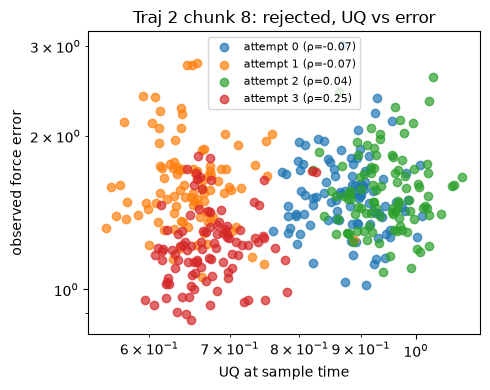

In [6]:
for traj_id, df in rejected_data.items():
    for chunk_id in sorted(df['chunk_id'].unique()):
        plot_chunk_uq_vs_error(traj_id, chunk_id, df[df['chunk_id'] == chunk_id])